In [1]:
'''
Here we assumed a diploid single locus, and we want to investigate the performance of different reproduction strategies on mutation rate evolution
under a diplod system. This simulation has been extended to 20KG and compared the mu evolution among different sexual frequencies. (RM)

Here N = 2000 and assuming 1% mutations are beneficial. Assuming the effect of mutations within modifier loci are additive.

Here this file plots the results of mitosis, and having RM every 1, 10, 100, 1K and 10K generations.



'''

'\nHere we assumed a diploid single locus, and we want to investigate the performance of different reproduction strategies on mutation rate evolution\nunder a diplod system. This simulation has been extended to 20KG and compared the mu evolution among different sexual frequencies. (RM)\n\nHere N = 2000 and assuming 1% mutations are beneficial. Assuming the effect of mutations within modifier loci are additive.\n\nHere this file plots the results of mitosis, and having RM every 1, 10, 100, 1K and 10K generations.\n\n'

In [2]:
from __future__ import division
import numpy as np
from scipy import stats
import scipy.spatial as spa
import numpy.random as rnd
import copy
import time
import pandas as pd
import math
import pickle
import seaborn as sns
import os

In [3]:
def get_data1(file_list):
    
    total_fit_mean = []
    total_fit_std = []
    
    total_soma_mu_bene_mean = []
    total_soma_mu_bene_std = []

    total_soma_mu_dele_mean = []
    total_soma_mu_dele_std = []
    
    
    for i in file_list:
        f = pd.read_csv(i,dtype=str)
    
        fit_mean = []
        fit_std = []
    
        soma_mu_bene_mean = []
        soma_mu_bene_std = []

        soma_mu_dele_mean = []
        soma_mu_dele_std = []
            
        
        fit_mean.extend(list(pd.Series(f.PopMeanFit_Mean,dtype=float)))
        fit_std.extend(list(pd.Series(f.PopMeanFit_STD,dtype=float)))
    
        soma_mu_bene_mean.extend(list(pd.Series(f.SomaMu_Bene_Mean,dtype=float)))
        soma_mu_bene_std.extend(list(pd.Series(f.SomaMu_Bene_Std,dtype=float)))

        soma_mu_dele_mean.extend(list(pd.Series(f.SomaMu_Dele_Mean,dtype=float)))
        soma_mu_dele_std.extend(list(pd.Series(f.SomaMu_Dele_Std,dtype=float)))
        
        
        
        total_fit_mean.append(fit_mean)
        total_fit_std.append(fit_std)
    
        total_soma_mu_bene_mean.append(soma_mu_bene_mean)
        total_soma_mu_bene_std.append(soma_mu_bene_std)  

        total_soma_mu_dele_mean.append(soma_mu_dele_mean)
        total_soma_mu_dele_std.append(soma_mu_dele_std)
        
        
        
    return total_fit_mean, total_fit_std, total_soma_mu_bene_mean, total_soma_mu_bene_std, \
total_soma_mu_dele_mean, total_soma_mu_dele_std

## N = 2K

In [4]:
os.chdir(r"D:\Prof. Azevedo\Simulation of Ciliate Evolution\20200212_Evolution of Mu Rate_Single Locus_1% Bene\Data\1. Diploid\1.1. N2K_1% Bene_Facultative Sex_Additive Mod")

In [5]:
n20_fit_file = ['Fit_Mito_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_RM_P2SN_N2K_Bene01_MuEvo_200207.csv', \
               'Fit_RME10M_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_RME100M_P2SN_N2K_Bene01_MuEvo_200207.csv',\
               'Fit_RME1KM_P2SN_N2K_Bene01_MuEvo_200207.csv', 'Fit_RME10KM_P2SN_N2K_Bene01_MuEvo_200207.csv']

n20 = get_data1(n20_fit_file)

n20_fit_mean =n20[0]
n20_fit_std = n20[1]

n20_sm_mu_bene_mean = n20[2]
n20_sm_mu_bene_std = n20[3]

n20_sm_mu_dele_mean = n20[4]
n20_sm_mu_dele_std = n20[5]

In [6]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 30})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(8)
    ax.spines['bottom'].set_linewidth(8)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=20, width=10, direction='out', pad=50, colors='black')

In [7]:
import matplotlib as lib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pylab
import pandas as pd
import os
import pickle
%matplotlib inline

In [8]:
generation_list = []

for i in range(20002):
    generation_list.append(i)
    
print(len(generation_list))

20002


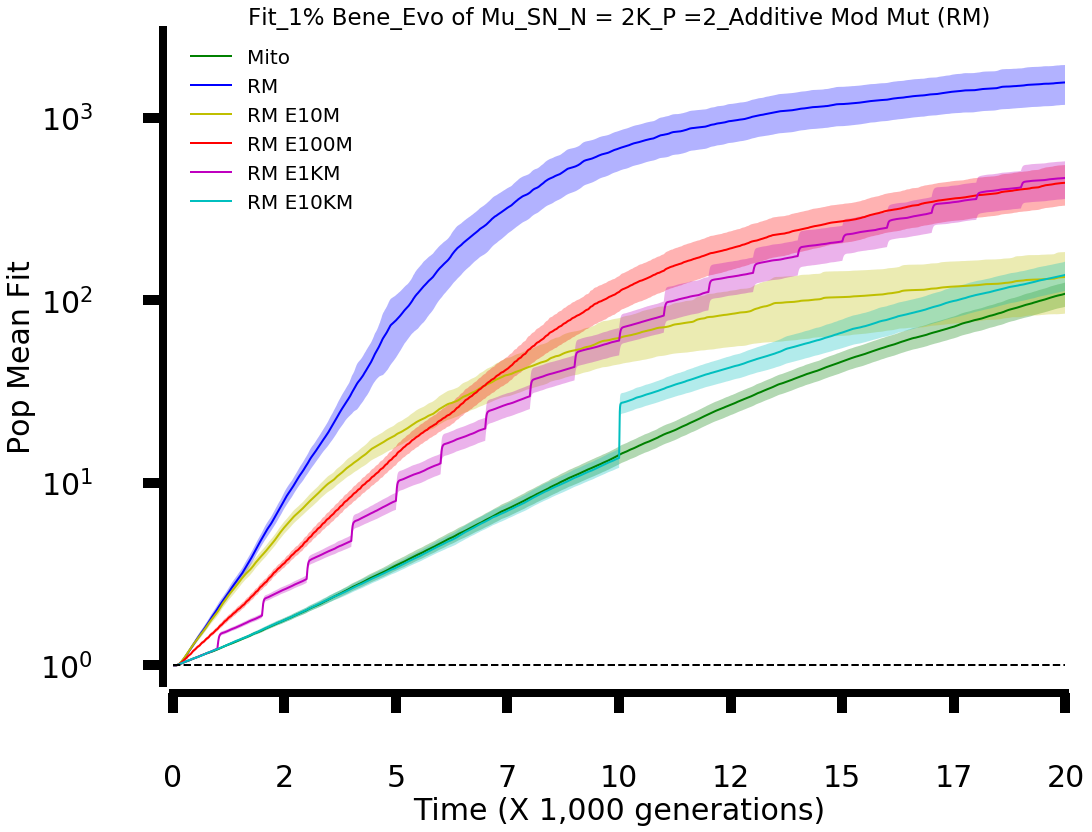

In [22]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)

t = generation_list

a1 = n20_fit_mean[0]
error_a1 = list(1.98* np.array(n20_fit_std[0])/((100)**0.5))


a2 = n20_fit_mean[1]
error_a2 = list(1.98* np.array(n20_fit_std[1])/((100)**0.5))


a3 = n20_fit_mean[2]
error_a3 = list(1.98* np.array(n20_fit_std[2])/((100)**0.5))


a4 = n20_fit_mean[3]
error_a4 = list(1.98* np.array(n20_fit_std[3])/((100)**0.5))


a5 = n20_fit_mean[4]
error_a5 = list(1.98* np.array(n20_fit_std[4])/((100)**0.5))


a6 = n20_fit_mean[5]
error_a6 = list(1.98* np.array(n20_fit_std[5])/((100)**0.5))



ax.set_title('Fit_1% Bene_Evo of Mu_SN_N = 2K_P =2_Additive Mod Mut (RM)', fontsize =23)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =30)
ax.set_ylabel('Pop Mean Fit', fontsize =30)


# ax.semilogy(t, a, )

ax.set_yscale('log')


ax.plot(t,a1,'g', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='g')

ax.plot(t,a2,'b', label = 'RM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'y', label = 'RM E10M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='y')


ax.plot(t,a4,'r', label = 'RM E100M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='r')


ax.plot(t,a5,'m', label = 'RM E1KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a5)- np.array(error_a5), np.array(a5)+ np.array(error_a5), alpha =0.3, facecolor='m')


ax.plot(t,a6,'c', label = 'RM E10KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a6)- np.array(error_a6), np.array(a6)+ np.array(error_a6), alpha =0.3, facecolor='c')


plt.axhline(y=1, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

plt.legend(loc=2, frameon=False, prop={'size':20})

# extraticks=[0.99]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.8, 3000)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

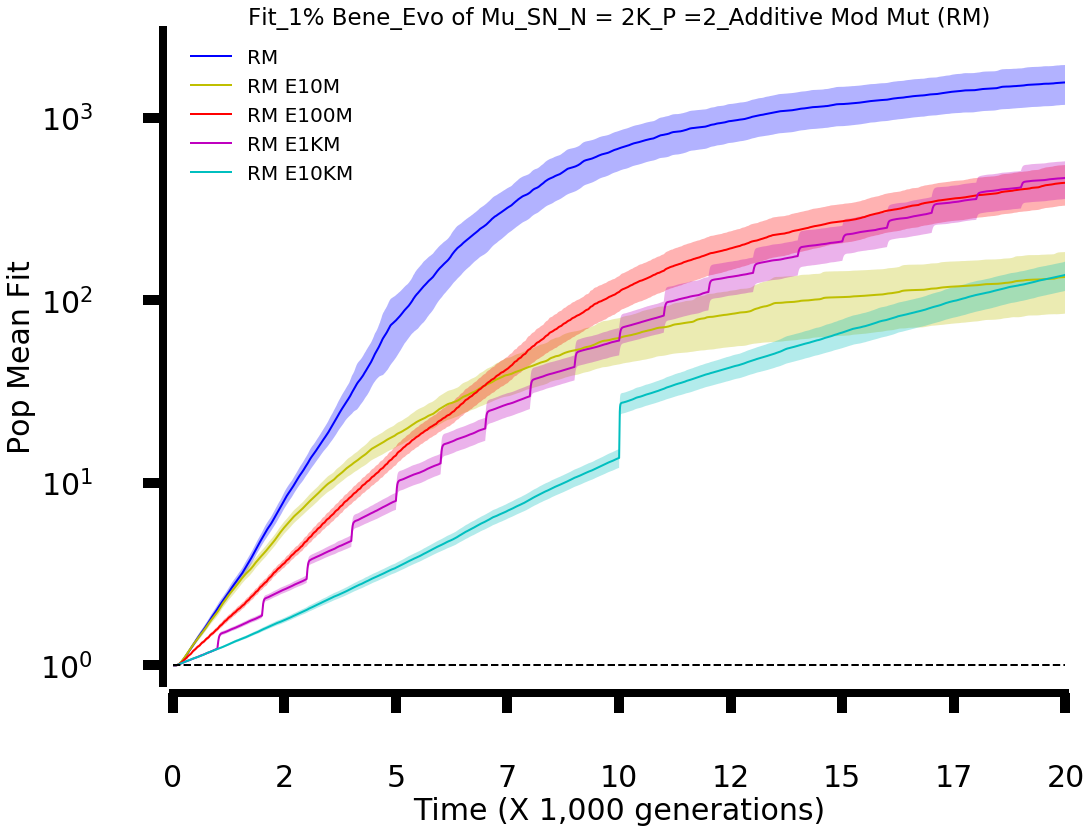

In [23]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)

t = generation_list

a1 = n20_fit_mean[0]
error_a1 = list(1.98* np.array(n20_fit_std[0])/((100)**0.5))


a2 = n20_fit_mean[1]
error_a2 = list(1.98* np.array(n20_fit_std[1])/((100)**0.5))


a3 = n20_fit_mean[2]
error_a3 = list(1.98* np.array(n20_fit_std[2])/((100)**0.5))


a4 = n20_fit_mean[3]
error_a4 = list(1.98* np.array(n20_fit_std[3])/((100)**0.5))


a5 = n20_fit_mean[4]
error_a5 = list(1.98* np.array(n20_fit_std[4])/((100)**0.5))


a6 = n20_fit_mean[5]
error_a6 = list(1.98* np.array(n20_fit_std[5])/((100)**0.5))



ax.set_title('Fit_1% Bene_Evo of Mu_SN_N = 2K_P =2_Additive Mod Mut (RM)', fontsize =23)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =30)
ax.set_ylabel('Pop Mean Fit', fontsize =30)


# ax.semilogy(t, a, )

ax.set_yscale('log')


# ax.plot(t,a1,'g', label = 'Mito',  linewidth=2.0, alpha =1)
# ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='g')

ax.plot(t,a2,'b', label = 'RM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'y', label = 'RM E10M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='y')


ax.plot(t,a4,'r', label = 'RM E100M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='r')


ax.plot(t,a5,'m', label = 'RM E1KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a5)- np.array(error_a5), np.array(a5)+ np.array(error_a5), alpha =0.3, facecolor='m')


ax.plot(t,a6,'c', label = 'RM E10KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a6)- np.array(error_a6), np.array(a6)+ np.array(error_a6), alpha =0.3, facecolor='c')


plt.axhline(y=1, linewidth=2.0, color ='k',ls ='dashed')

ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

plt.legend(loc=2, frameon=False, prop={'size':20})

# extraticks=[0.99]
# ax.set_yticks(list(ax.get_yticks()) + extraticks)

ax.set_ylim(0.8, 3000)



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

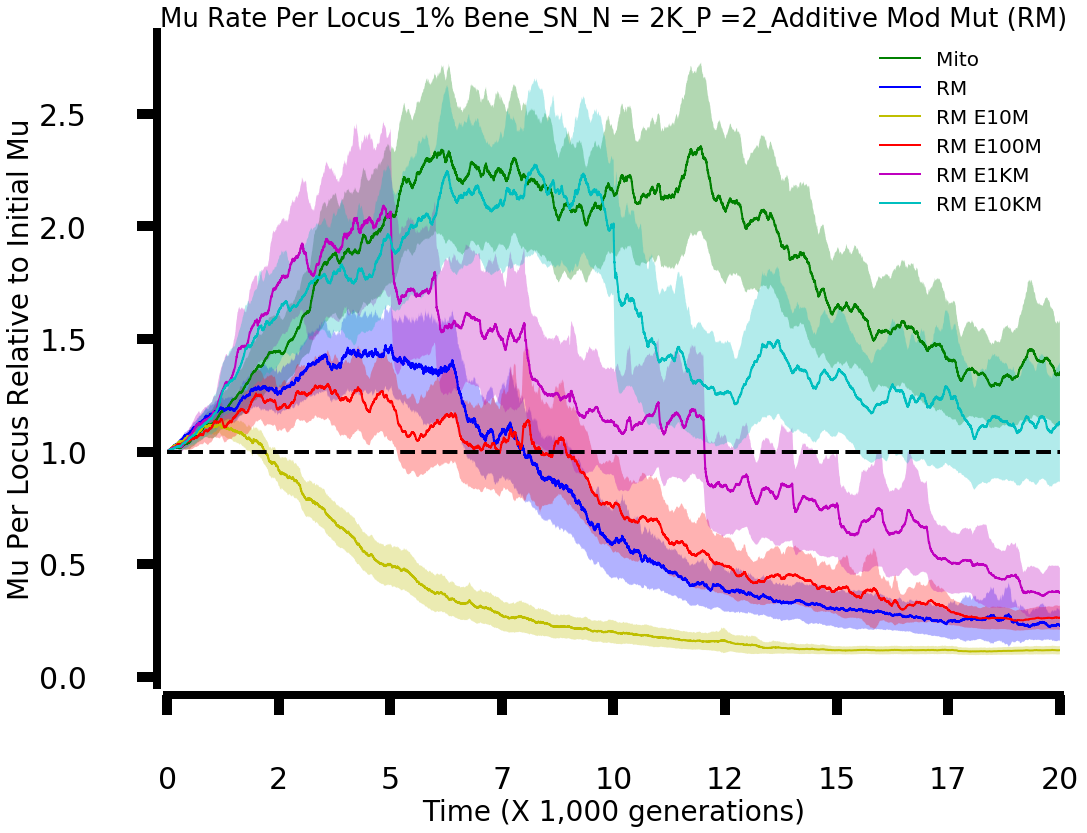

In [16]:
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)
# ax.scatter(0,0)

ax.set_xlim(0,20*1000)

t = generation_list

a1 = np.array(n20_sm_mu_dele_mean[0])/(0.1*2/45/(2*100))
error_a1 = 1.98* np.array(n20_sm_mu_dele_std[0])/((100)**0.5)/(0.1*2/45/(2*100))


a2 = np.array(n20_sm_mu_dele_mean[1])/(0.1*2/45/(2*100))
error_a2 = 1.98* np.array(n20_sm_mu_dele_std[1])/((100)**0.5)/(0.1*2/45/(2*100))


a3 = np.array(n20_sm_mu_dele_mean[2])/(0.1*2/45/(2*100))
error_a3 = 1.98* np.array(n20_sm_mu_dele_std[2])/((100)**0.5)/(0.1*2/45/(2*100))


a4 = np.array(n20_sm_mu_dele_mean[3])/(0.1*2/45/(2*100))
error_a4 = 1.98* np.array(n20_sm_mu_dele_std[3])/((100)**0.5)/(0.1*2/45/(2*100))


a5 = np.array(n20_sm_mu_dele_mean[4])/(0.1*2/45/(2*100))
error_a5 = 1.98* np.array(n20_sm_mu_dele_std[4])/((100)**0.5)/(0.1*2/45/(2*100))


a6 = np.array(n20_sm_mu_dele_mean[5])/(0.1*2/45/(2*100))
error_a6 = 1.98* np.array(n20_sm_mu_dele_std[5])/((100)**0.5)/(0.1*2/45/(2*100))




ax.set_title('Mu Rate Per Locus_1% Bene_SN_N = 2K_P =2_Additive Mod Mut (RM)', fontsize =26)
ax.set_xlabel('Time (X 1,000 generations)', fontsize =28)
ax.set_ylabel('Mu Per Locus Relative to Initial Mu', fontsize =28)


# ax.semilogy(t, a, )

# ax.set_yscale('log')

ax.plot(t,a1,'g', label = 'Mito',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a1)- np.array(error_a1), np.array(a1)+ np.array(error_a1), alpha =0.3, facecolor='g')

ax.plot(t,a2,'b', label = 'RM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a2)- np.array(error_a2), np.array(a2)+ np.array(error_a2), alpha =0.3, facecolor='b')


ax.plot(t,a3,'y', label = 'RM E10M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a3)- np.array(error_a3), np.array(a3)+ np.array(error_a3), alpha =0.3, facecolor='y')


ax.plot(t,a4,'r', label = 'RM E100M',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a4)- np.array(error_a4), np.array(a4)+ np.array(error_a4), alpha =0.3, facecolor='r')


ax.plot(t,a5,'m', label = 'RM E1KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a5)- np.array(error_a5), np.array(a5)+ np.array(error_a5), alpha =0.3, facecolor='m')


ax.plot(t,a6,'c', label = 'RM E10KM',  linewidth=2.0, alpha =1)
ax.fill_between(t, np.array(a6)- np.array(error_a6), np.array(a6)+ np.array(error_a6), alpha =0.3, facecolor='c')

plt.axhline(y= (0.1*2/45/(2*100))/(0.1*2/45/(2*100)), linewidth=4.0, color ='k',ls ='dashed')


ax.minorticks_off()
# ax.yaxis.set_ticks(np.arange(start, end, 0.1))

plt.legend(loc=1, frameon=False, prop={'size':20})



# plt.show()
plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

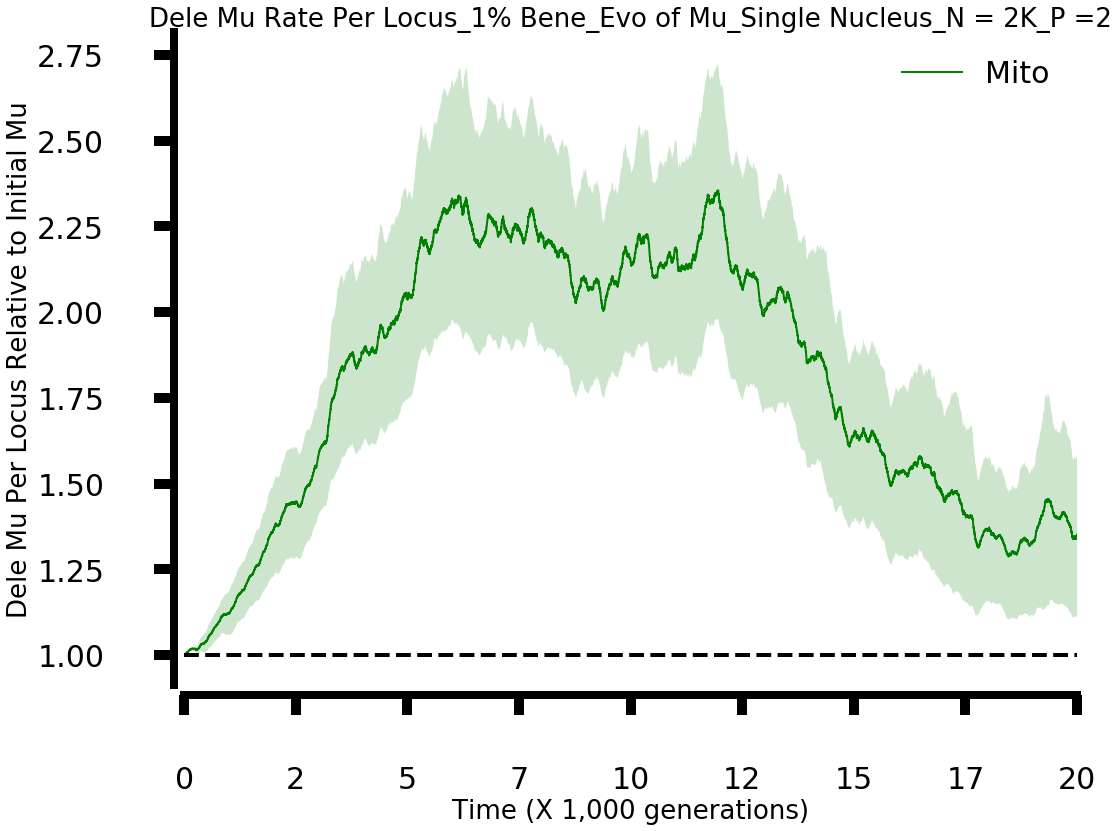

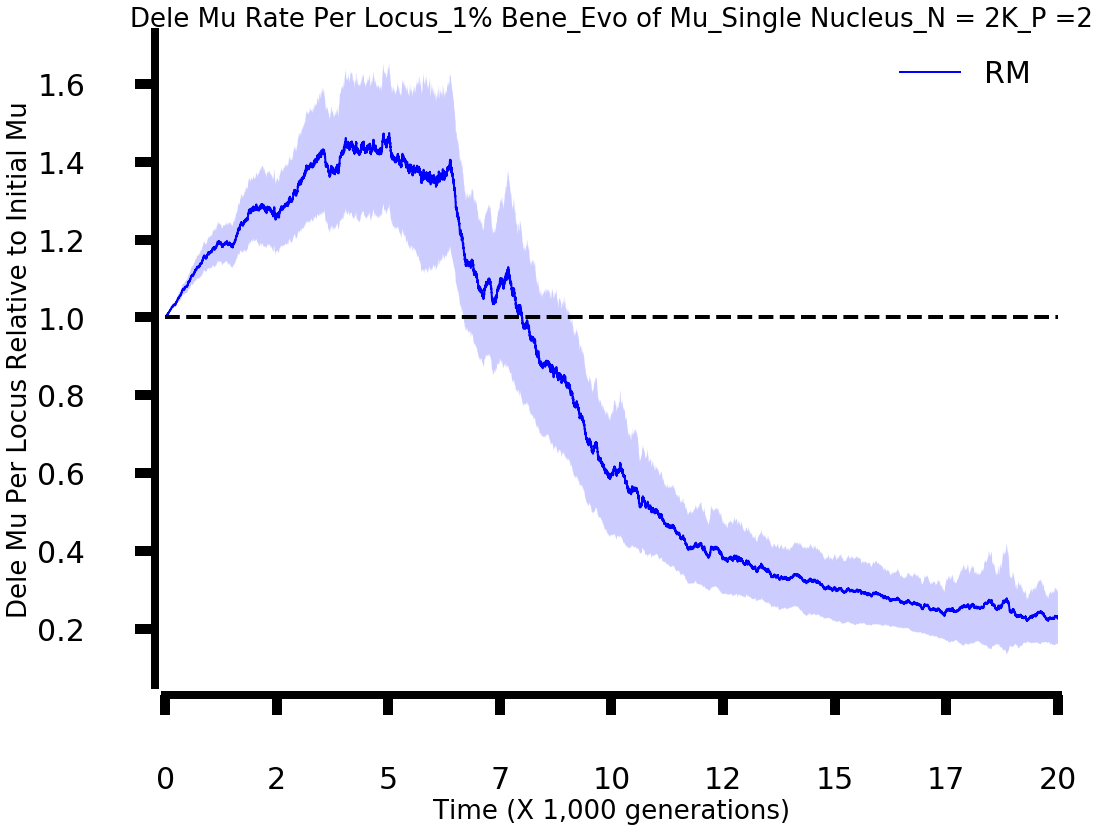

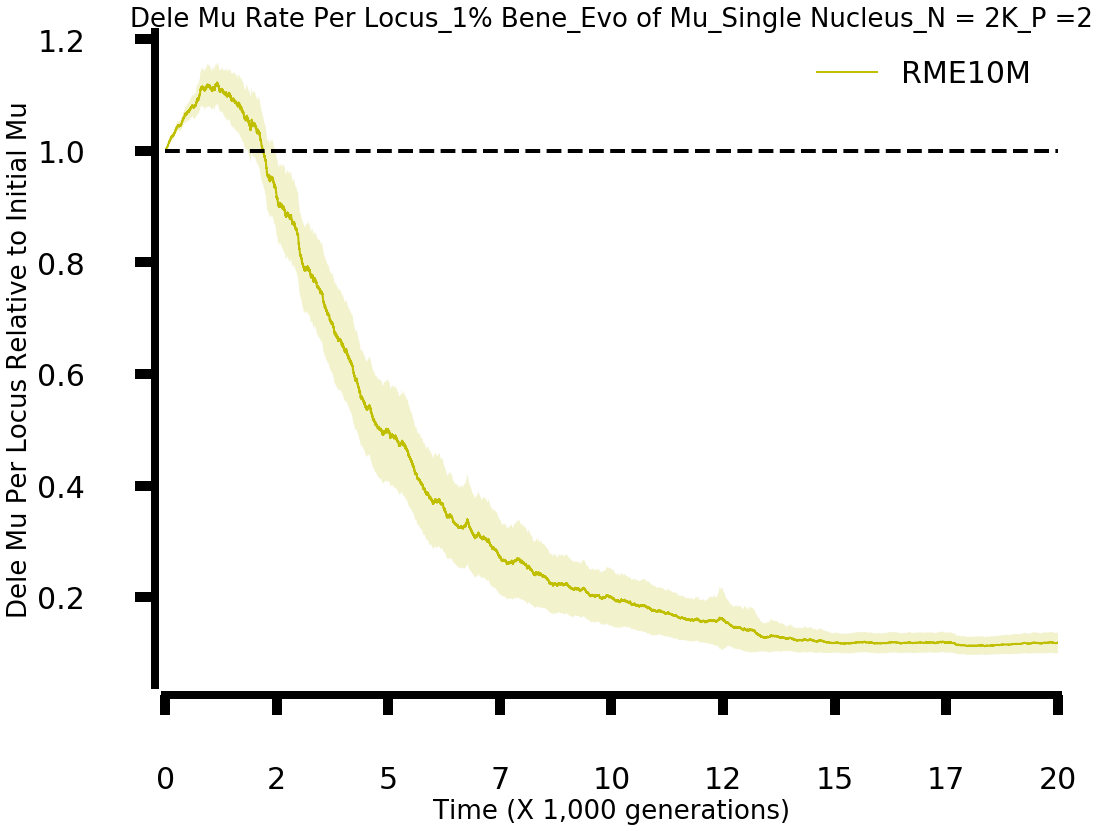

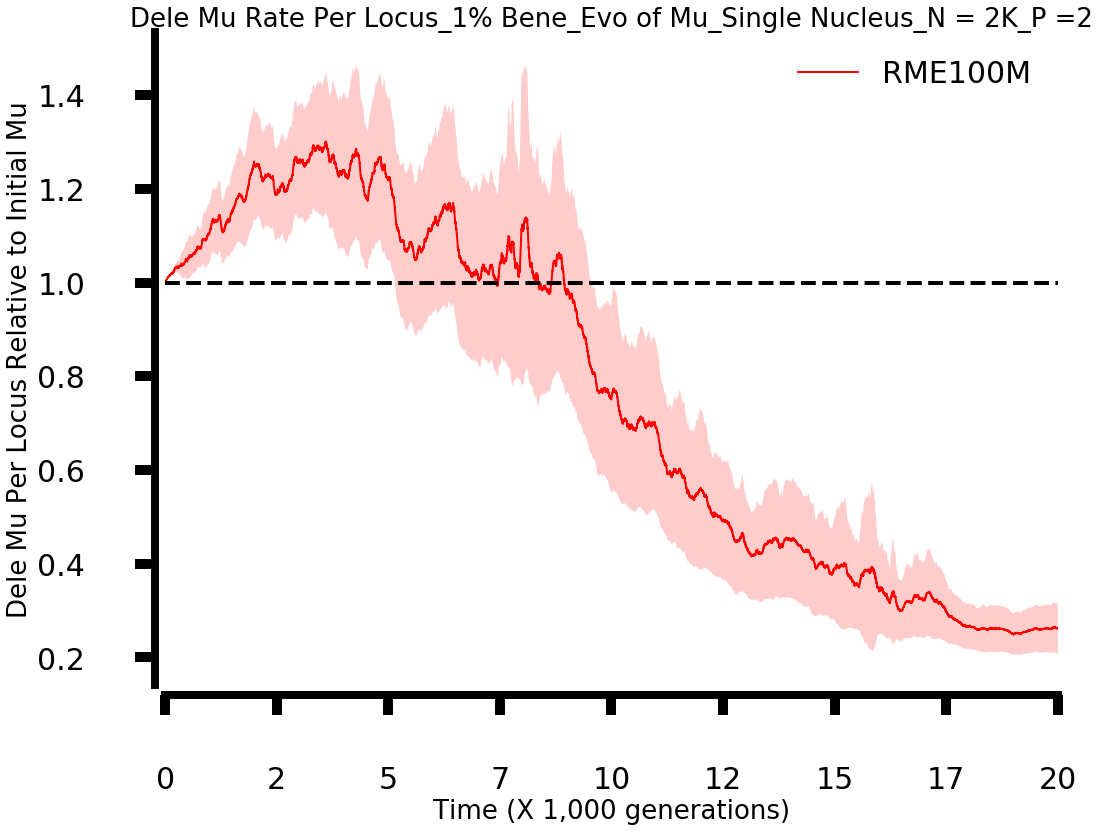

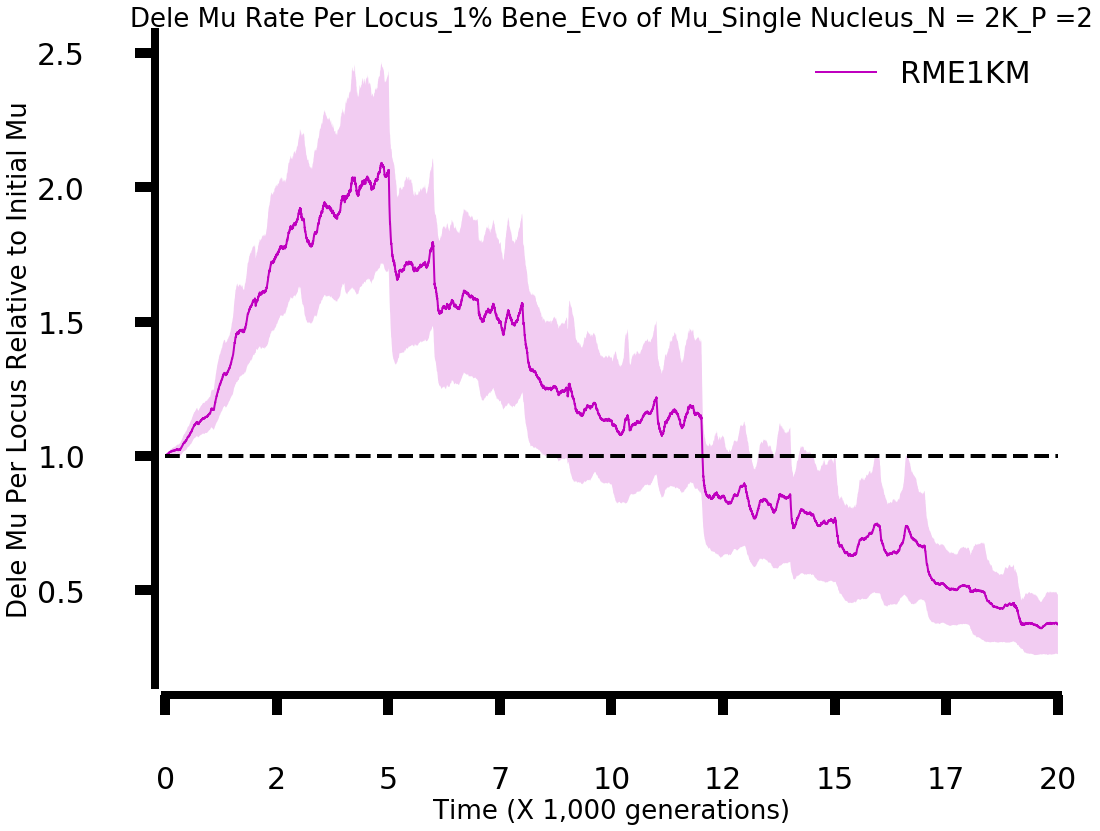

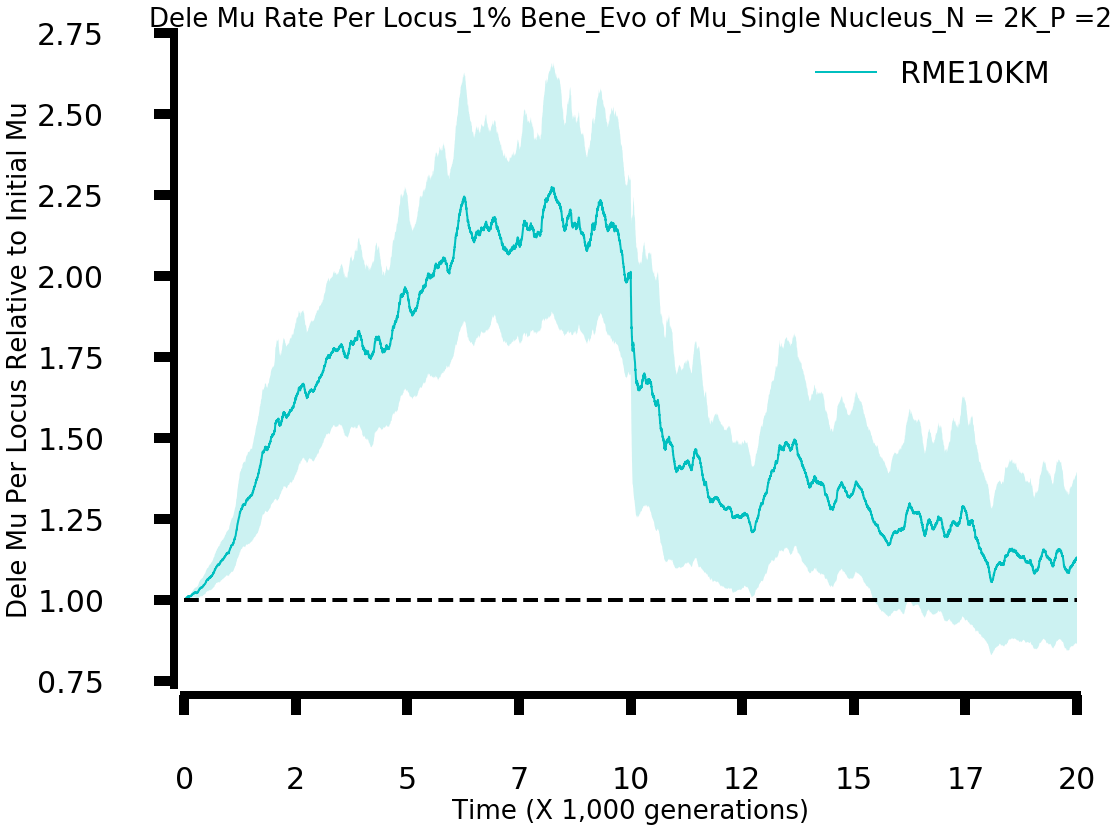

In [24]:
for i in range(6):
    
    
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111)
    publication_figure(ax)
    # ax.scatter(0,0)

    ax.set_xlim(0,20*1000)

    t = generation_list

    a1 = np.array(n20_sm_mu_dele_mean[0])/(0.1/(45*100))
    error_a1 = 1.98* np.array(n20_sm_mu_dele_std[0])/((100)**0.5)/(0.1/(45*100))


    a2 = np.array(n20_sm_mu_dele_mean[1])/(0.1/(45*100))
    error_a2 = 1.98* np.array(n20_sm_mu_dele_std[1])/((100)**0.5)/(0.1/(45*100))


    a3 = np.array(n20_sm_mu_dele_mean[2])/(0.1/(45*100))
    error_a3 = 1.98* np.array(n20_sm_mu_dele_std[2])/((100)**0.5)/(0.1/(45*100))


    a4 = np.array(n20_sm_mu_dele_mean[3])/(0.1/(45*100))
    error_a4 = 1.98* np.array(n20_sm_mu_dele_std[3])/((100)**0.5)/(0.1/(45*100))


    a5 = np.array(n20_sm_mu_dele_mean[4])/(0.1/(45*100))
    error_a5 = 1.98* np.array(n20_sm_mu_dele_std[4])/((100)**0.5)/(0.1/(45*100))


    a6 = np.array(n20_sm_mu_dele_mean[5])/(0.1/(45*100))
    error_a6 = 1.98* np.array(n20_sm_mu_dele_std[5])/((100)**0.5)/(0.1/(45*100))
    
 
    

    fit_mean = [a1, a2, a3, a4, a5, a6]
    fit_errorbar = [error_a1, error_a2, error_a3, error_a4, error_a5, error_a6]

    rp_strategy = ['Mito', 'RM', 'RME10M', 'RME100M', 'RME1KM', 'RME10KM']

    color = ['g', 'b','y', 'r', 'm', 'c']

    ax.set_title('Dele Mu Rate Per Locus_1% Bene_Evo of Mu_Single Nucleus_N = 2K_P =2', fontsize =26)
    ax.set_xlabel('Time (X 1,000 generations)', fontsize =26)
    
    ax.set_ylabel('Dele Mu Per Locus Relative to Initial Mu', fontsize =26)
    ax.plot(t,fit_mean[i],color[i], label = rp_strategy[i],  linewidth=2.0, alpha =1)
    ax.fill_between(t, np.array(fit_mean[i])- np.array(fit_errorbar[i]), np.array(fit_mean[i])+ np.array(fit_errorbar[i]), alpha =0.2, facecolor=color[i])


    plt.axhline(y= 0.1/(45*100)/(0.1/(45*100)), linewidth=4.0, color ='k',ls ='dashed')

    ax.minorticks_off()

    plt.legend(loc=1, frameon=False, prop={'size':30})

    plt.gca().get_xaxis().set_major_formatter(FuncFormatter(lambda x, p: format(int(x/1000), ',')))

### Check whether the Ctrl Loci have been mutation-fixed

In [25]:
import pickle

In [26]:
def read_file(file_name):
    with open(file_name, 'rb') as f:
        x = pickle.load(f)
        
    return x

In [27]:
def read_file_list(file_list):    
    
    total_x = []
    for i in file_list:
        with open(i, 'rb') as f:
            x = pickle.load(f)
            total_x.append(x)
    return total_x

In [28]:
sm_upper_file = ['Mito_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', 
                'RM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'RME10M_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'RME100M_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'RME1KM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207', \
                'RME10KM_P2SN_N2K_Bene01_SM_Ctrl_Upper_200207']

In [29]:
sm_lower_file = ['Mito_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', 
                'RM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'RME10M_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'RME100M_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'RME1KM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207', \
                'RME10KM_P2SN_N2K_Bene01_SM_Ctrl_Lower_200207']

In [30]:
sm_upper = read_file_list(sm_upper_file)
sm_lower = read_file_list(sm_lower_file)

In [31]:
def check_mut_fix(loci_array, fix_num):
    
    nRep, nInd, nLoci = loci_array[0].shape[0:3]
    
    fix_loci_mean = []
    fix_loci_std = []
    for i in loci_array:
        fix_loci = np.sum(np.sum(i== fix_num,axis=1)==nInd,axis=1)
        fix_loci_mean.append(np.nanmean(fix_loci))
        fix_loci_std.append(np.nanstd(fix_loci))
    
    return fix_loci_mean, fix_loci_std

In [32]:
sm_upper_fix = check_mut_fix(sm_upper, 2)
sm_upper_fix 

([2.0299999999999998,
  1.3700000000000001,
  0.38,
  1.6399999999999999,
  2.75,
  2.6099999999999999],
 [1.7858051405458548,
  1.1371455491712572,
  0.59632206063502302,
  1.2846789482201382,
  1.6209565077447328,
  1.7486852203870198])

In [33]:
sm_lower_fix = check_mut_fix(sm_lower, 2)
sm_lower_fix 

([0.42999999999999999,
  1.3200000000000001,
  1.28,
  1.23,
  1.47,
  0.97999999999999998],
 [0.57017541160593732,
  0.63055531081737792,
  0.47074409183759275,
  0.44395945760846228,
  0.60753600716336142,
  0.74806416837060175])

In [34]:
def publication_figure(axis):
    plt.rcParams.update({'font.size': 20})
    ax = axis
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_linewidth(4)
    ax.spines['bottom'].set_linewidth(4)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    #ax.xaxis.set_ticks([])
    ax.tick_params(axis='x', which='both', bottom='on', top='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')
    ax.tick_params(axis='y', which='both', left='on', right='off',labelbottom='on', size=10, width=5, direction='out', pad=25, colors='black')

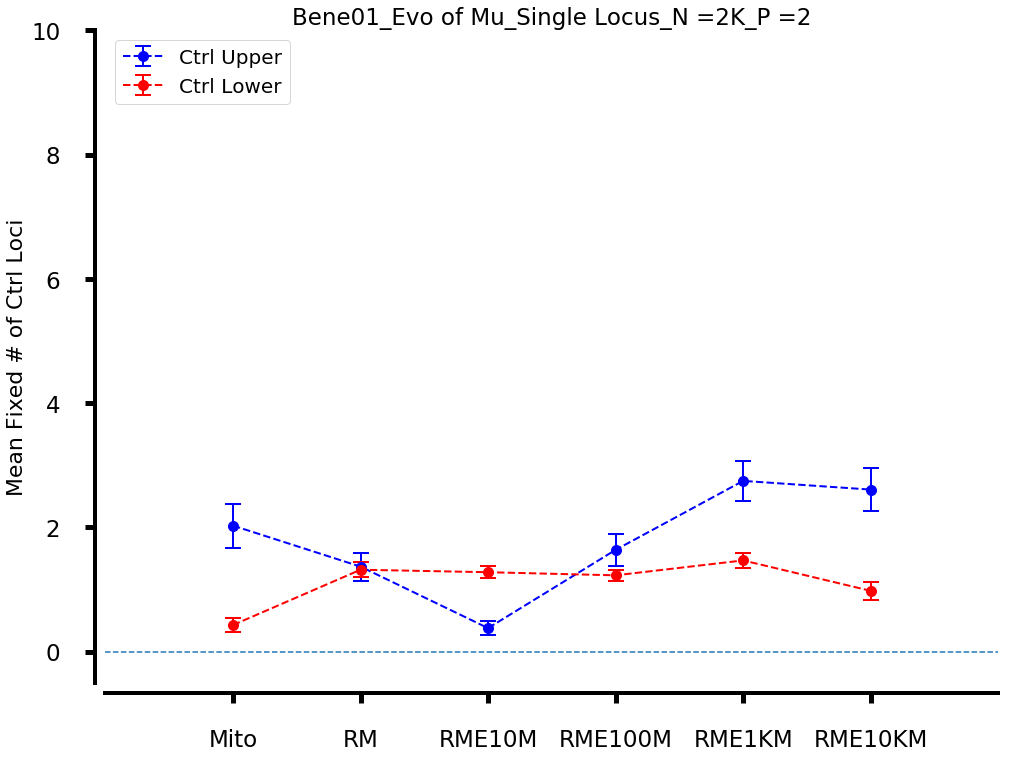

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pylab

%matplotlib inline

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111)
publication_figure(ax)

mean1 = sm_upper_fix [0]
error_bar1 = 1.98*np.array(sm_upper_fix[1])/(100**0.5)

mean2 = sm_lower_fix [0]
error_bar2 = 1.98*np.array(sm_lower_fix[1])/(100**0.5)



plt.errorbar( xrange(6), mean1, yerr=error_bar1, label = 'Ctrl Upper', color = 'b', fmt='o', ls = '--', markersize =10, lw=2, capsize=8, capthick=2)
plt.errorbar( xrange(6), mean2, yerr=error_bar2, label = 'Ctrl Lower', color = 'r', fmt='o', ls = '--', markersize =10, lw=2, capsize=8, capthick=2)


plt.title('Bene01_Evo of Mu_Single Locus_N =2K_P =2', fontsize =23)
plt.ylabel('Mean Fixed # of Ctrl Loci', fontsize =22)
plt.axhline(y=0, xmin=0, xmax=22, ls ='dashed')

 

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

x = range(6)
my_xticks = ['Mito', 'RM', 'RME10M','RME100M', 'RME1KM', 'RME10KM']
plt.xticks(x, my_xticks, rotation =0)

plt.tick_params(axis='both', labelsize=23)

plt.legend(loc='upper left')

# legend = ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., fontsize =15)
# frame = legend.get_frame()
# # frame.set_framecolor('black')
# frame.set_edgecolor('black')


plt.xlim(-1, 6)
plt.ylim(-0.5, 10)


plt.show()